# Exercise Sheet: Machine Learning with the California Housing Dataset

Duration: ~4 hours

Level: Master’s (physics / data science)

Tools: Python, pandas, matplotlib, scikit-learn


## Learning goals

By the end of this session, you should be able to:

- Load and explore real-world datasets
- Understand feature distributions and correlations
- Prepare data for machine learning
- Train and evaluate regression models
- Interpret model performance and limitations

## Part 0 - Setup (15 min)
Exercise 0.1 - Download and load the dataset

Use the provided code to:

- Download the dataset
- Extract it
- Load it into a pandas DataFrame

### Task

Print the first 5 rows
Check the shape of the dataset

In [235]:
import os
import tarfile
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# URL of the dataset (compressed .tgz file from GitHub)
# -----------------------------------------------------------
HOUSING_URL = "https://github.com/ageron/data/raw/main/housing.tgz"

# -----------------------------------------------------------
# Define local directories and file paths
# -----------------------------------------------------------
DOWNLOAD_DIR = "datasets"                     # main folder for all datasets
TGZ_PATH = os.path.join(DOWNLOAD_DIR, "housing.tgz")  # path to downloaded file
EXTRACT_DIR = os.path.join(DOWNLOAD_DIR, "housing")   # where CSV will be extracted

# -----------------------------------------------------------
# Function to download and extract the dataset
# -----------------------------------------------------------
def download_and_extract_data(url=HOUSING_URL, tgz_path=TGZ_PATH, extract_dir=EXTRACT_DIR):
    
    # Create the dataset directory if it does not exist
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)

    # -------------------------------------------------------
    # Download step (ONLY if file does not already exist)
    # -------------------------------------------------------
    if not os.path.exists(tgz_path):
        print("Downloading dataset...")
        urllib.request.urlretrieve(url, tgz_path)
        print("Download complete.")
    else:
        print("Dataset already downloaded. Skipping download.")

    # -------------------------------------------------------
    # Extraction step (ONLY if not already extracted)
    # -------------------------------------------------------
    if not os.path.exists(extract_dir):
        print("Extracting dataset...")
        with tarfile.open(tgz_path) as tar:
            tar.extractall(path=DOWNLOAD_DIR)
        print("Extraction complete.")
    else:
        print("Dataset already extracted. Skipping extraction.")

# -----------------------------------------------------------
# Function to load the CSV into a pandas DataFrame
# -----------------------------------------------------------
def load_housing_data(csv_path=os.path.join(EXTRACT_DIR, "housing.csv")):
    
    # Check if file exists before loading
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"CSV file not found at {csv_path}. "
            "Make sure the dataset is downloaded and extracted."
        )

    print("Loading dataset into pandas DataFrame...")
    df = pd.read_csv(csv_path)

    return df

    
# Step 1: Download and extract dataset (if needed)
download_and_extract_data()

# Step 2: Load dataset into pandas
housing_df = load_housing_data()

# Step 3: Basic inspection
housing_df.head()



Dataset already downloaded. Skipping download.
Dataset already extracted. Skipping extraction.
Loading dataset into pandas DataFrame...


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Exercise 0.2 — Basic inspection

Questions

- How many features are there?
- What are their names?
- Which feature is the target variable?



We can check for `ocean_proximity` since its type is object, while others are numerical

In [236]:
# Info
print("\n Dataset info")
housing_df.info()
housing_df.dtypes
housing_df.describe()


 Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [237]:
# Proximity Test
prox = housing_df["ocean_proximity"]
prox.value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

We can check the summary of the numerical attributes

## Part 1 — Data Exploration (45 min)

### Exercise 1.1 — Visualizing distributions

Plot histograms of all features:

Questions

- Which variables are skewed?
- Are there outliers?
- Which feature looks discretized?

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

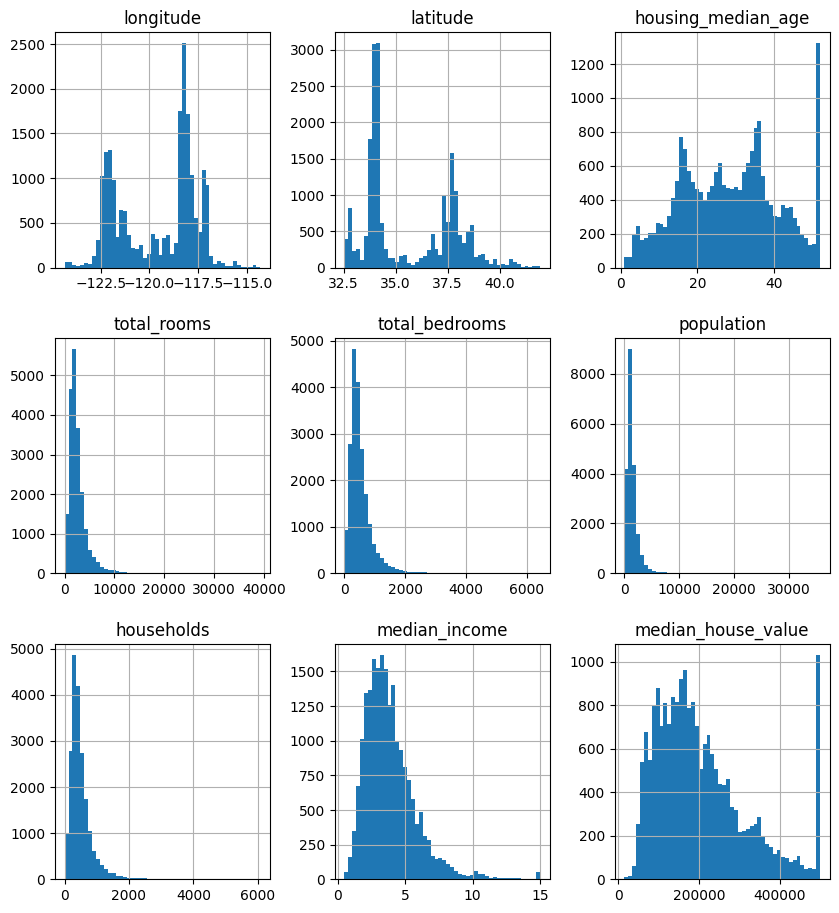

In [238]:
#Plot for features
housing_df.hist(bins = 50, figsize = (10,11))


### Exercise 1.2 — Geographic visualization

Plot longitude vs latitude (both simple and with some beautiful colours):

Questions

- Where are the most expensive houses located?
- What patterns do you see?

<Axes: xlabel='longitude', ylabel='latitude'>

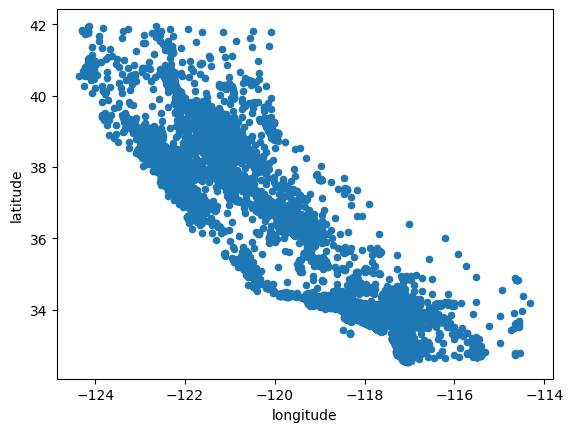

In [239]:
#Longitude vs Latitude Simple
housing_df.plot('longitude', 'latitude', kind = 'scatter')

<Axes: xlabel='longitude', ylabel='latitude'>

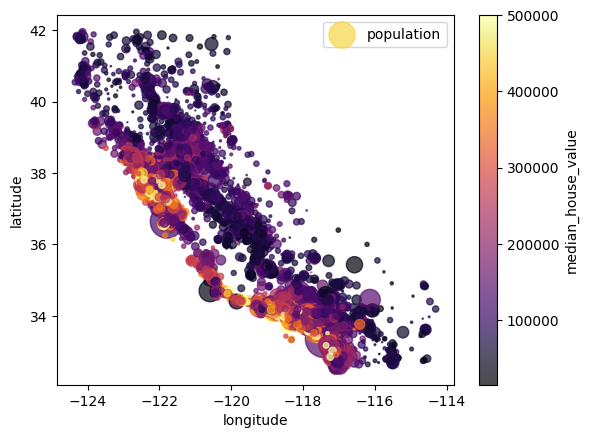

In [240]:
#Longitude vs Latitude Fancy
housing_df.plot('longitude', 'latitude', c ='median_house_value', kind = 'scatter', s = housing_df['population']/50, alpha = 0.7, cmap = 'inferno', label = 'population')

### Exercise 1.3 — Correlation analysis

Compute correlation matrix:

Task

Find the features most correlated with median_house_value

Question

Which variable is the strongest predictor?

In [241]:
housing_df.corr(method = 'pearson', min_periods = 1, numeric_only = True)
#Median Income


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


array([[<Axes: xlabel='longitude', ylabel='longitude'>,
        <Axes: xlabel='latitude', ylabel='longitude'>,
        <Axes: xlabel='housing_median_age', ylabel='longitude'>,
        <Axes: xlabel='total_rooms', ylabel='longitude'>,
        <Axes: xlabel='total_bedrooms', ylabel='longitude'>,
        <Axes: xlabel='population', ylabel='longitude'>,
        <Axes: xlabel='households', ylabel='longitude'>,
        <Axes: xlabel='median_income', ylabel='longitude'>,
        <Axes: xlabel='median_house_value', ylabel='longitude'>],
       [<Axes: xlabel='longitude', ylabel='latitude'>,
        <Axes: xlabel='latitude', ylabel='latitude'>,
        <Axes: xlabel='housing_median_age', ylabel='latitude'>,
        <Axes: xlabel='total_rooms', ylabel='latitude'>,
        <Axes: xlabel='total_bedrooms', ylabel='latitude'>,
        <Axes: xlabel='population', ylabel='latitude'>,
        <Axes: xlabel='households', ylabel='latitude'>,
        <Axes: xlabel='median_income', ylabel='latitude'>,
    

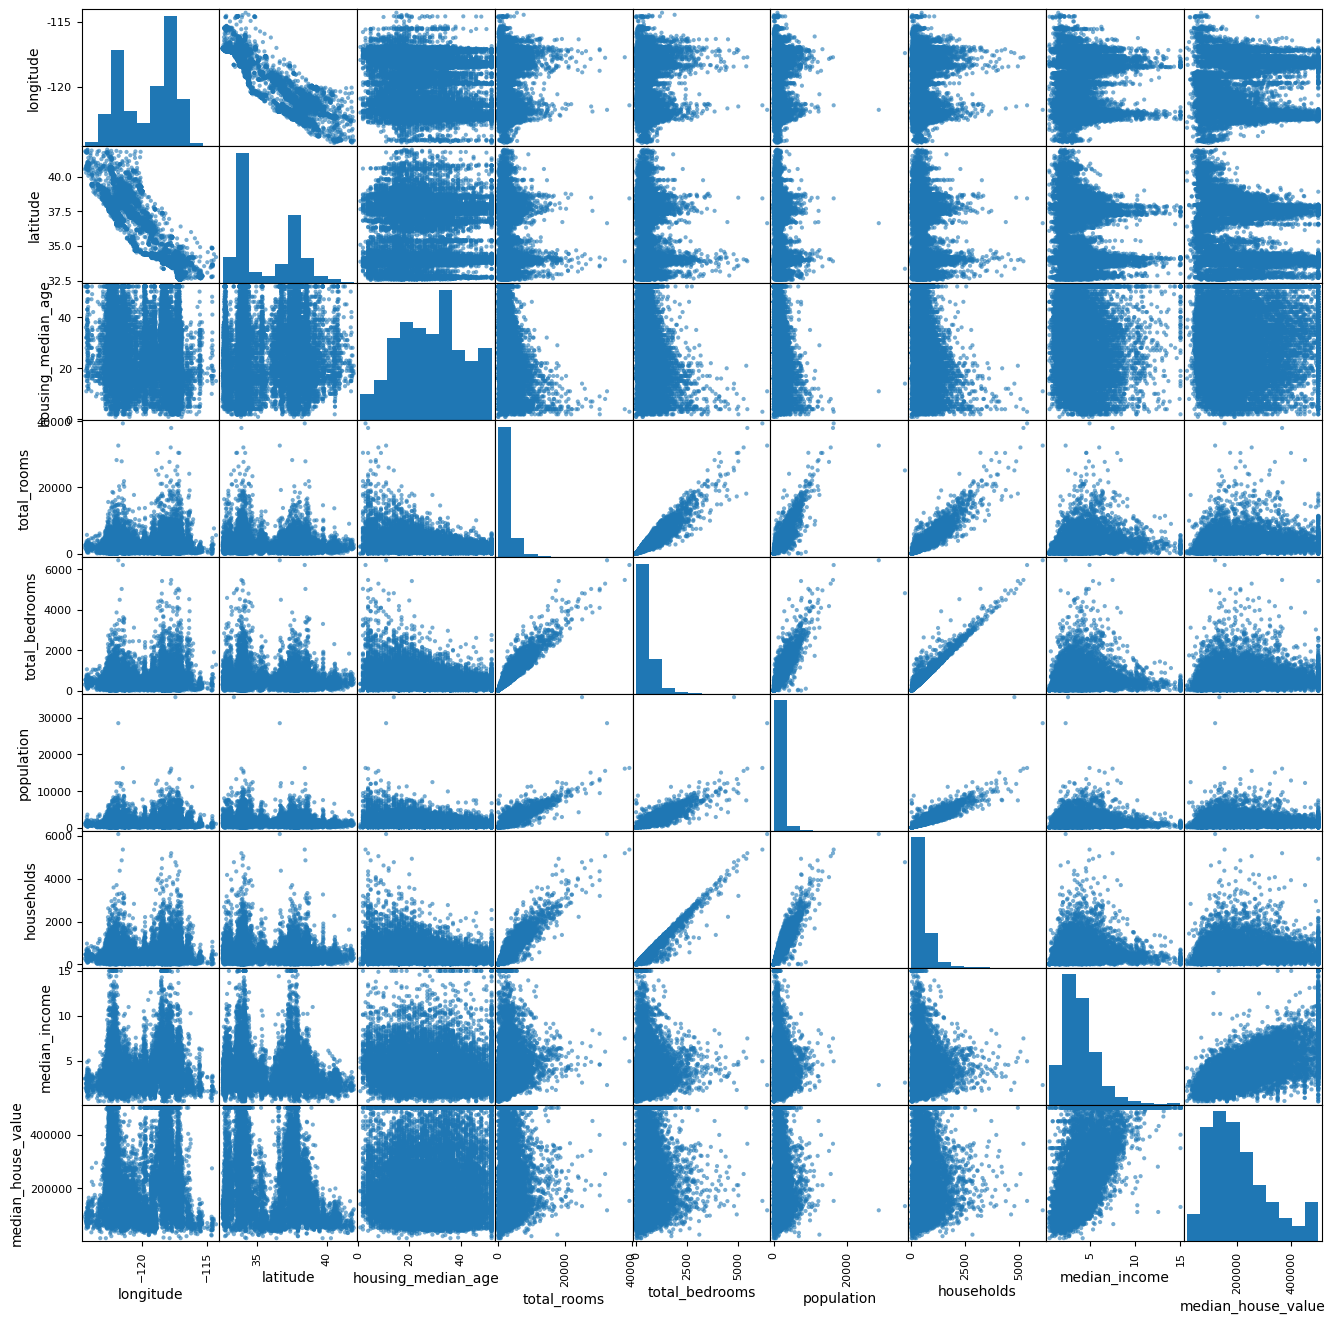

In [242]:
pd.plotting.scatter_matrix(housing_df, figsize= (16,16), alpha=0.6)


## Part 2 - Data Preparation (60 min)
### Exercise 2.1 - Train/test split

Split data:

Question

Why do we split the dataset?

In [243]:
import numpy as np
train_set, test_set = train_test_split(housing_df, test_size=0.2, random_state=42)

### Exercise 2.2 — Stratified sampling

Create income categories:

Plot it

What is stratified sampling (intuition)

Instead of splitting your dataset randomly, you split it in a way that preserves the distribution of an important variable.

In this dataset, that variable is:
`median_income`

Why do we care here?

House prices depend strongly on income.

If you do a purely random split:

- you might accidentally get too many rich districts in train
- and too many poor districts in test

Result: your model evaluation becomes biased / unreliable

In [244]:
income_cat = pd.cut(
    housing_df["median_income"],
    bins=[0., 2.5, 5.0, 7.5, 10., 12.5, 15.0, np.inf],
    labels=[1, 2, 3, 4, 5, 6, 7]
)

<Axes: xlabel='median_income'>

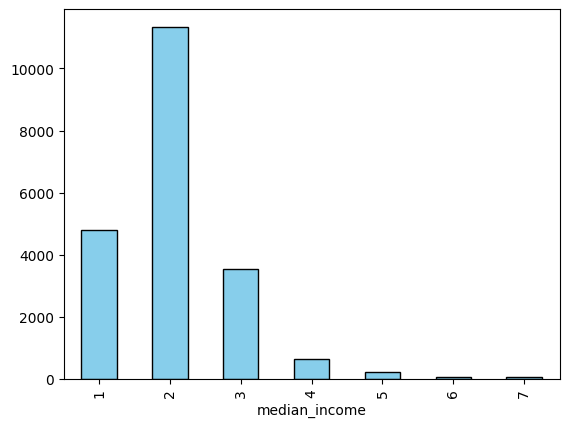

In [245]:


income_cat.value_counts().sort_index().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

### Exercise 2.3 — Handling missing values

Identify missing values:

In [246]:
from sklearn.impute import SimpleImputer

In [247]:
# Identify and sum up all instances when there is no data in a given column
housing_df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [248]:
imputer = SimpleImputer(strategy="median")

# Select only numerical columns
housing_num = housing_df.drop("ocean_proximity", axis=1)

# Fit + transform
housing_num_imputed = imputer.fit_transform(housing_num)

### Exercise 2.4 — Feature engineering

Create new features:

In [249]:
housing_df["rooms_per_household"] = housing_df["total_rooms"] / housing_df["households"]
housing_df["bedrooms_per_room"] = housing_df["total_bedrooms"] / housing_df["total_rooms"]
housing_df["population_per_household"] = housing_df["population"] / housing_df["households"]

Question

Why might these features help?

### Exercise 2.5 — Categorical variables

Encode ocean_proximity:

In [250]:
# Remove the helper column used only for stratification
for set_ in (train_set, test_set):
    if "income_cat" in set_.columns:
        set_.drop("income_cat", axis=1, inplace=True)

# Add the engineered features to BOTH train and test sets
for set_ in (train_set, test_set):
    set_["rooms_per_household"] = set_["total_rooms"] / set_["households"]
    set_["bedrooms_per_room"] = set_["total_bedrooms"] / set_["total_rooms"]
    set_["population_per_household"] = set_["population"] / set_["households"]

# Separate inputs (X) and target (y)
X_train = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"].copy()

X_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"].copy()

# Separate numerical and categorical columns
X_train_num = X_train.drop("ocean_proximity", axis=1)
X_test_num = X_test.drop("ocean_proximity", axis=1)

X_train_cat = X_train[["ocean_proximity"]]
X_test_cat = X_test[["ocean_proximity"]]

# Impute missing numerical values using ONLY the training set
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train_num_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train_num.index
)

X_test_num_imputed = pd.DataFrame(
    imputer.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test_num.index
)

# One-hot encode the categorical column using ONLY the training set
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")

X_train_cat_encoded = pd.DataFrame(
    encoder.fit_transform(X_train_cat).toarray(),
    columns=encoder.get_feature_names_out(["ocean_proximity"]),
    index=X_train_cat.index
)

X_test_cat_encoded = pd.DataFrame(
    encoder.transform(X_test_cat).toarray(),
    columns=encoder.get_feature_names_out(["ocean_proximity"]),
    index=X_test_cat.index
)

# Final prepared datasets for machine learning
X_train_prepared = pd.concat([X_train_num_imputed, X_train_cat_encoded], axis=1)
X_test_prepared = pd.concat([X_test_num_imputed, X_test_cat_encoded], axis=1)

print("Training set shape:", X_train_prepared.shape)
print("Test set shape:", X_test_prepared.shape)
X_train_prepared.head()

Training set shape: (16512, 16)
Test set shape: (4128, 16)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,-117.22,32.75,34.0,6001.0,1111.0,2654.0,1072.0,4.5878,5.597948,0.185136,2.475746,0.0,0.0,0.0,0.0,1.0
8267,-117.03,32.69,10.0,901.0,163.0,698.0,167.0,4.6648,5.395210,0.180910,4.179641,0.0,0.0,0.0,0.0,1.0
17445,-122.27,37.74,28.0,6909.0,1554.0,2974.0,1484.0,3.6875,4.655660,0.224924,2.004043,0.0,0.0,0.0,1.0,0.0
14265,-121.82,37.25,25.0,4021.0,634.0,2178.0,650.0,5.1663,6.186154,0.157672,3.350769,1.0,0.0,0.0,0.0,0.0
2271,-115.98,33.32,8.0,240.0,46.0,63.0,24.0,1.4688,10.000000,0.191667,2.625000,0.0,1.0,0.0,0.0,0.0


## Part 3 - Linear Regression

### Exercise 3.1 — Look at a few predictions

New cell

In [251]:
from sklearn.linear_model import LinearRegression

clf = LinearRegression() #Here is the AI model
clf.fit(X_train_prepared, y_train)
Res = clf.predict(X_test_prepared)
results_df = pd.DataFrame()
results_df['predicted_values'] = clf.predict(X_test_prepared)

<function matplotlib.pyplot.show(close=None, block=None)>

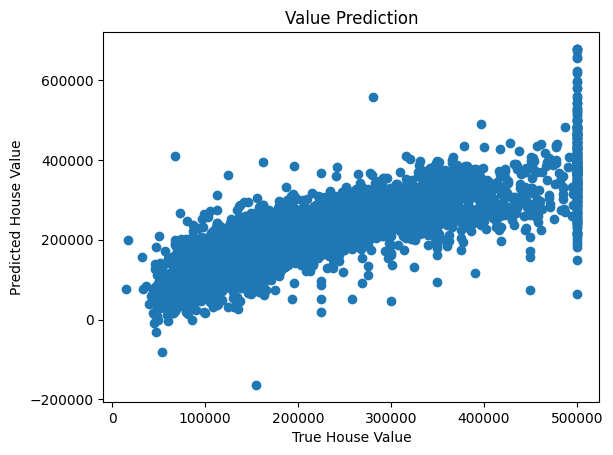

In [252]:
plt.scatter(y_test, results_df['predicted_values'])
plt.xlabel("True House Value")
plt.ylabel("Predicted House Value")
plt.title("Value Prediction")
plt.show

Questions for students

- Are the predictions close to the true values?
- Does the model always overestimate, always underestimate, or both?
- Are there cases where the prediction error is very large?

### Exercise 3.2 — Compute residuals

Explain that the residual is: $$ residual = y_{true} - y_{cell}$$



Questions

- What does a positive residual mean?
- What does a negative residual mean?
- If residuals are centered around zero, what does that suggest?

In [253]:
#results_df["residual"].describe()

Questions

- What is the mean residual?
- Is it close to zero?
- What is the standard deviation of the residuals?

### Exercise 3.4 — Plot true vs predicted values

This is one of the best linear-regression exercises.

Questions

- What would a perfect model look like on this plot?
- Do the points follow the diagonal?
- In which region does the model perform worse?

### Exercise 3.9 — Standardize the numerical variables and retrain

Still linear regression, but now you learn why preprocessing matters.

In [254]:
from sklearn.preprocessing import StandardScaler

num_cols = X_train_num_imputed.columns

scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num_imputed),
    columns=num_cols,
    index=X_train_num_imputed.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num_imputed),
    columns=num_cols,
    index=X_test_num_imputed.index
)

X_train_prepared_scaled = pd.concat([X_train_num_scaled, X_train_cat_encoded], axis=1)
X_test_prepared_scaled = pd.concat([X_test_num_scaled, X_test_cat_encoded], axis=1)

In [255]:
lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_prepared_scaled, y_train)

y_pred_scaled = lin_reg_scaled.predict(X_test_prepared_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))

print("Test RMSE with scaling:", rmse_scaled)

NameError: name 'mean_squared_error' is not defined